# Laboratory Work: Data Preparation for Machine Learning

### Goal

Learn the main steps of preparing a dataset before training a machine learning model.

In this laboratory work we will practice:

- inspecting a dataset;
- identifying duplicate samples and redundant features;
- finding and imputing missing values;
- identifying outliers;
- transforming numerical variables;
- encoding categorical variables;
- splitting data into training and test sets;
- fitting preprocessing **only on the training data**;
- combining preprocessing and classification in a `Pipeline`.

The dataset is based on the **Breast Cancer Wisconsin** dataset from `scikit-learn`, but it has been intentionally modified to contain common data-quality problems.

> Main idea: **good machine learning starts with good data preparation**.


## 0. Import libraries

If a package is missing, uncomment the installation line.


In [3]:
# If needed, uncomment:
# !pip install numpy pandas matplotlib scikit-learn

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.feature_selection import SelectKBest, f_classif

RANDOM_STATE = 42


## 1. Load the dataset

Keep `messy_breast_cancer_data.csv` in the same folder as this notebook.


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/vytkuc/inf4039_2026_autumn/refs/heads/main/lab01_data_prep/messy_breast_cancer_data.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (577, 12)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean symmetry,target,device,size_group,constant_feature
0,15.780,22.91,105.70,782.6,0.11550,0.17520,0.21330,0.2096,0,Device_B,large,1
1,21.610,22.28,144.40,1407.0,0.11670,0.20870,0.28100,0.2162,0,Device_B,large,1
2,15.050,19.07,97.26,701.9,0.09215,0.08597,0.07486,0.1561,0,Device_A,large,1
3,6.981,13.43,43.79,143.5,0.11700,0.07568,0.00000,0.1930,1,Device_B,small,1
4,14.040,15.98,89.78,611.2,0.08458,0.05895,0.03534,0.1714,1,Device_B,NaN,1


## 2. Initial inspection

Before changing anything, first understand the dataset.

Useful questions:

- How many samples and features are there?
- What are the data types?
- Are there missing values?
- Are there duplicate rows?
- Do some features contain only one unique value?


In [5]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nNumber of unique values per column:")
print(df.nunique(dropna=False).sort_values())


Shape: (577, 12)

Data types:
mean radius         float64
mean texture        float64
mean perimeter      float64
mean area           float64
mean smoothness     float64
mean compactness    float64
mean concavity      float64
mean symmetry       float64
target                int64
device               object
size_group           object
constant_feature      int64
dtype: object

Missing values per column:
size_group          24
mean concavity      24
device              23
mean radius         22
mean smoothness     22
mean perimeter      21
mean area           19
mean compactness    17
mean symmetry       16
mean texture        10
target               0
constant_feature     0
dtype: int64

Number of duplicate rows: 8

Number of unique values per column:
constant_feature      1
target                2
size_group            4
device                4
mean symmetry       426
mean radius         441
mean smoothness     458
mean texture        472
mean perimeter      505
mean concavity      5

In [6]:
# Basic descriptive statistics for numerical variables
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,555.0,14.567223,6.787148,6.98100,11.710000,13.40000,16.090000,110.0000
mean texture,567.0,19.699383,6.472480,9.71000,16.325000,18.90000,21.840000,100.0000
mean perimeter,556.0,91.902770,24.426592,43.79000,74.967500,86.04000,103.875000,188.5000
mean area,558.0,659.124552,357.053174,143.50000,418.975000,548.70000,796.650000,2501.0000
mean smoothness,555.0,0.096519,0.013916,0.05263,0.086720,0.09610,0.105400,0.1634
mean compactness,560.0,0.105177,0.053370,0.01938,0.065318,0.09509,0.130525,0.3454
mean concavity,553.0,0.089094,0.079950,0.00000,0.029580,0.06154,0.132100,0.4268
mean symmetry,561.0,0.181303,0.027435,0.10600,0.161900,0.17940,0.195700,0.3040
target,577.0,0.623917,0.484822,0.00000,0.000000,1.00000,1.000000,1.0000
constant_feature,577.0,1.000000,0.000000,1.00000,1.000000,1.00000,1.000000,1.0000


### Visual inspection

Boxplots are useful for spotting unusually large or small values.


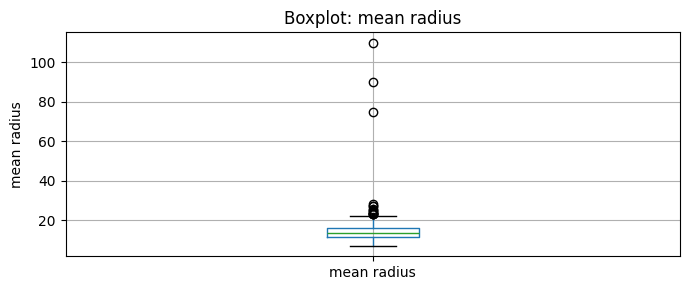

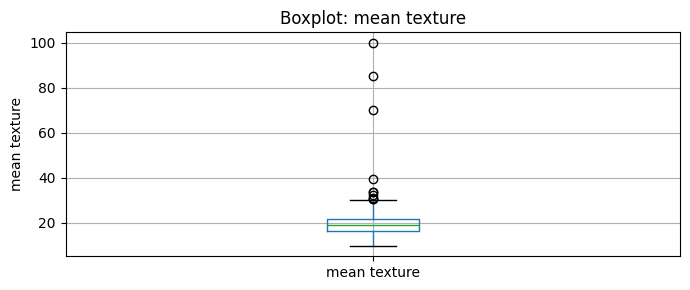

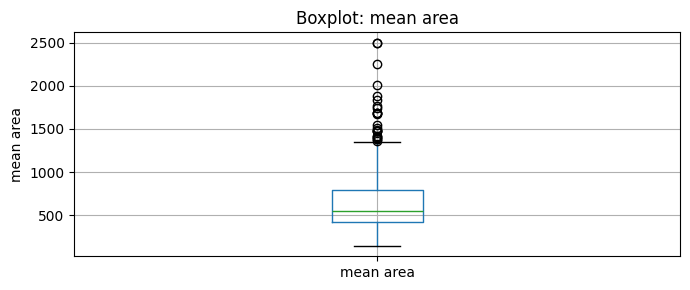

In [7]:
for column in ["mean radius", "mean texture", "mean area"]:
    plt.figure(figsize=(7, 3))
    df[[column]].boxplot()
    plt.title(f"Boxplot: {column}")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


## 3. Redundant samples and redundant features

Two simple problems are:

1. **Duplicate samples** – the same row appears more than once.
2. **Zero-variance features** – a feature contains the same value for every sample.

We remove exact duplicate rows before the train/test split so that the same sample cannot appear in both datasets.


In [8]:
df_clean = df.copy()

print("Rows before removing duplicates:", len(df_clean))
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df_clean))

zero_variance_features = [
    col for col in df_clean.columns
    if col != "target" and df_clean[col].nunique(dropna=True) <= 1
]

print("\nZero-variance features:", zero_variance_features)

df_clean = df_clean.drop(columns=zero_variance_features)

print("Shape after basic cleaning:", df_clean.shape)


Rows before removing duplicates: 577
Rows after removing duplicates: 569

Zero-variance features: ['constant_feature']
Shape after basic cleaning: (569, 11)


## 4. Split the data into training and test sets

The target variable is `target`:

- `0` – malignant;
- `1` – benign.

A key rule is:

> **Split first. Fit data-preparation parameters on the training set only. Then apply the same transformations to both training and test data.**

This helps prevent **data leakage**.


In [9]:
X = df_clean.drop(columns="target")
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())


Training samples: 398
Test samples: 171

Training class counts:
target
0    148
1    250
Name: count, dtype: int64


## 5. Missing values

Common options for missing values include:

- removal;
- mean imputation;
- median imputation;
- most-frequent-value imputation;
- constant-value imputation;
- KNN imputation.

For numerical variables, the **median** is often useful when outliers are present.
For categorical variables, the **most frequent value** is a simple choice.


In [10]:
print("Missing values in the training set:")
X_train.isna().sum().sort_values(ascending=False)


Missing values in the training set:


,0
size_group,18
device,18
mean concavity,18
mean perimeter,17
mean radius,15
mean smoothness,14
mean compactness,13
mean area,13
mean symmetry,12
mean texture,5


### 5.1 Simple imputation example

Here we impute one numerical feature using the training-set median.


In [11]:
example_feature = "mean radius"

median_imputer = SimpleImputer(strategy="median")

train_radius = X_train[[example_feature]]
train_radius_imputed = median_imputer.fit_transform(train_radius)

print("Training-set median used for imputation:",
      float(median_imputer.statistics_[0]))

print("Missing values before:", train_radius.isna().sum().iloc[0])
print("Missing values after:", np.isnan(train_radius_imputed).sum())


Training-set median used for imputation: 13.28
Missing values before: 15
Missing values after: 0


### 5.2 KNN imputation example

`KNNImputer` estimates missing values using nearby samples.

This is more flexible than replacing every missing value with one global number, but it is also more computationally expensive.


In [12]:
knn_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
]

knn_imputer = KNNImputer(n_neighbors=5)

X_knn = knn_imputer.fit_transform(X_train[knn_features])

print("Shape after KNN imputation:", X_knn.shape)
print("Remaining missing values:", np.isnan(X_knn).sum())


Shape after KNN imputation: (398, 4)
Remaining missing values: 0


## 6. Outliers

An outlier may represent:

- a measurement or input error;
- corrupted data;
- a valid but unusual observation.

We should **identify outliers first**, not automatically delete every unusual value.

Two common methods are:

- standard deviation;
- interquartile range (IQR).


### 6.1 IQR method

A common rule marks values outside:

- `Q1 - 1.5 × IQR`
- `Q3 + 1.5 × IQR`


In [13]:
feature = "mean radius"

values = X_train[feature].dropna()

q1 = values.quantile(0.25)
q3 = values.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (X_train[feature] < lower) | (X_train[feature] > upper)

print("Q1:", round(q1, 3))
print("Q3:", round(q3, 3))
print("IQR:", round(iqr, 3))
print("Lower limit:", round(lower, 3))
print("Upper limit:", round(upper, 3))
print("Identified outliers:", int(outlier_mask.sum()))

X_train.loc[outlier_mask, [feature]]


Q1: 11.705
Q3: 15.78
IQR: 4.075
Lower limit: 5.593
Upper limit: 21.892
Identified outliers: 10


,mean radius
340,23.29
161,25.73
525,23.51
324,24.63
506,27.42
13,90.00
378,23.27
160,23.09
262,75.00
338,24.25


### 6.2 Standard-deviation method

Here we identify values farther than three standard deviations from the mean.


In [14]:
feature = "mean texture"

values = X_train[feature].dropna()

mean_value = values.mean()
std_value = values.std()

lower = mean_value - 3 * std_value
upper = mean_value + 3 * std_value

outliers_std = values[(values < lower) | (values > upper)]

print("Mean:", round(mean_value, 3))
print("Standard deviation:", round(std_value, 3))
print("Lower limit:", round(lower, 3))
print("Upper limit:", round(upper, 3))
print("Identified outliers:", len(outliers_std))

outliers_std


Mean: 19.769
Standard deviation: 6.743
Lower limit: -0.46
Upper limit: 39.998
Identified outliers: 2


,mean texture
535,100.0
159,85.0


## 7. Transforming numerical variables

The lecture introduces several common transformations:

- **Min-Max normalization** – usually maps values to `[0, 1]`;
- **standardization** – centers values around 0 and scales by standard deviation;
- **robust scaling** – uses the median and IQR and is less sensitive to outliers;
- **power transformation** – changes the distribution to be more Gaussian-like.

We fit every transformation on the **training data only**.


In [15]:
feature = "mean radius"

# First remove missing values only for this small demonstration.
demo_imputer = SimpleImputer(strategy="median")
x = demo_imputer.fit_transform(X_train[[feature]])

scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
}

scaled_versions = {}

for name, scaler in scalers.items():
    scaled_versions[name] = scaler.fit_transform(x).ravel()

comparison = pd.DataFrame({
    "Original": x.ravel(),
    "MinMax": scaled_versions["MinMax"],
    "Standard": scaled_versions["Standard"],
    "Robust": scaled_versions["Robust"],
})

comparison.describe().T


,count,mean,std,min,25%,50%,75%,max
Original,398.0,1.435061e+01,5.914812,6.981000,11.740000,13.280000,15.722500,90.000000
MinMax,398.0,8.877014e-02,0.071246,0.000000,0.057324,0.075874,0.105295,1.000000
Standard,398.0,-2.410132e-16,1.001259,-1.247526,-0.441923,-0.181232,0.232234,12.805920
Robust,398.0,2.688281e-01,1.485201,-1.581670,-0.386692,0.000000,0.613308,19.264281


### 7.1 Power transformation example


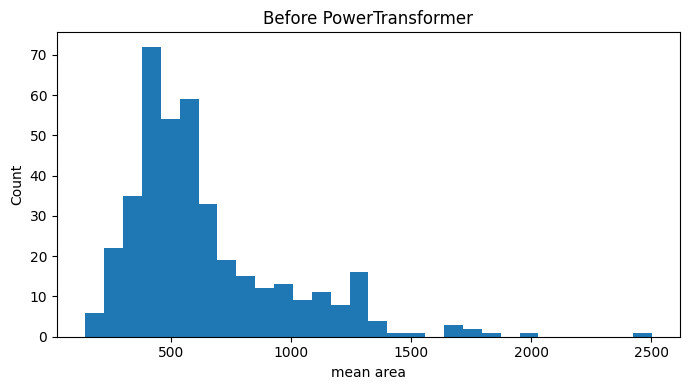

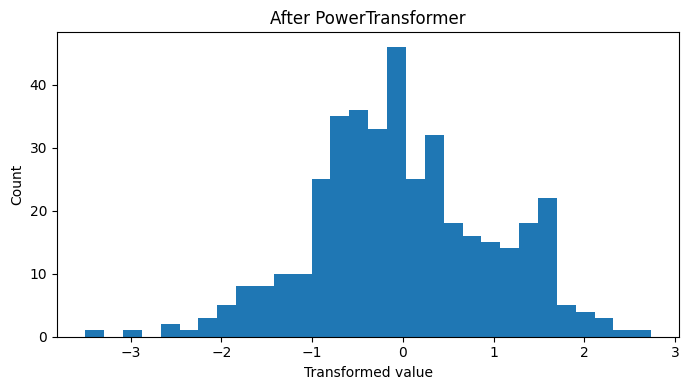

In [16]:
feature = "mean area"

area_imputer = SimpleImputer(strategy="median")
area = area_imputer.fit_transform(X_train[[feature]])

power = PowerTransformer()
area_power = power.fit_transform(area)

plt.figure(figsize=(7, 4))
plt.hist(area.ravel(), bins=30)
plt.title("Before PowerTransformer")
plt.xlabel(feature)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(area_power.ravel(), bins=30)
plt.title("After PowerTransformer")
plt.xlabel("Transformed value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 8. Categorical variables

This dataset contains two categorical variables:

- `device` – **nominal** categories with no natural order;
- `size_group` – **ordinal** categories: `small < medium < large`.

We therefore use:

- `OneHotEncoder` for `device`;
- `OrdinalEncoder` for `size_group`.


In [17]:
# Nominal variable
nominal_imputer = SimpleImputer(strategy="most_frequent")
device_train = nominal_imputer.fit_transform(X_train[["device"]])

one_hot = OneHotEncoder(handle_unknown="ignore")
device_encoded = one_hot.fit_transform(device_train)

print("One-hot categories:")
print(one_hot.categories_)
print("Encoded shape:", device_encoded.shape)

# Ordinal variable
ordinal_imputer = SimpleImputer(strategy="most_frequent")
size_train = ordinal_imputer.fit_transform(X_train[["size_group"]])

ordinal_encoder = OrdinalEncoder(
    categories=[["small", "medium", "large"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

size_encoded = ordinal_encoder.fit_transform(size_train)

print("\nFirst 10 ordinal values:")
print(size_encoded[:10].ravel())


One-hot categories:
[array(['Device_A', 'Device_B', 'Device_C'], dtype=object)]
Encoded shape: (398, 3)

First 10 ordinal values:
[1. 0. 1. 1. 1. 2. 1. 2. 1. 0.]


## 9. Build one complete preprocessing pipeline

Instead of preprocessing each feature manually, we can combine the steps.

For this dataset:

- numerical variables → median imputation + `RobustScaler`;
- nominal categorical variable → most-frequent imputation + one-hot encoding;
- ordinal categorical variable → most-frequent imputation + ordinal encoding.

Then we train a Logistic Regression classifier.

Using a `Pipeline` is useful because the same preprocessing is applied consistently during training and testing.


In [18]:
numeric_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean symmetry",
]

nominal_features = ["device"]
ordinal_features = ["size_group"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["small", "medium", "large"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("nominal", nominal_pipeline, nominal_features),
    ("ordinal", ordinal_pipeline, ordinal_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))


Accuracy: 0.912
Balanced accuracy: 0.902


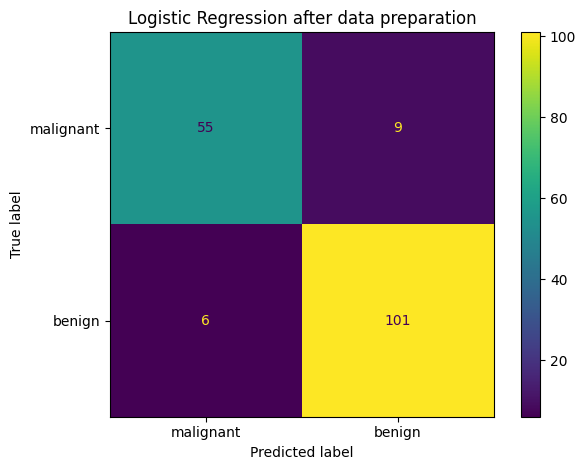

In [19]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["malignant", "benign"]
)
plt.title("Logistic Regression after data preparation")
plt.tight_layout()
plt.show()


## 10. Compare different scalers

Because the dataset contains deliberately added outliers, compare:

- `MinMaxScaler`;
- `StandardScaler`;
- `RobustScaler`.

All other preprocessing steps remain the same.


In [20]:
def build_model_with_scaler(scaler):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler),
    ])

    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=[["small", "medium", "large"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("nominal", nominal_pipeline, nominal_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])


results = []

for scaler_name, scaler in {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
}.items():

    current_model = build_model_with_scaler(scaler)
    current_model.fit(X_train, y_train)
    pred = current_model.predict(X_test)

    results.append({
        "Scaler": scaler_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
    })

results_df = pd.DataFrame(results)
results_df.round(3)


,Scaler,Accuracy,Balanced Accuracy
0,MinMaxScaler,0.860,0.850
1,StandardScaler,0.912,0.902
2,RobustScaler,0.912,0.902


## 11. Optional: simple feature selection

Feature selection keeps only the most useful features.

Here we use `SelectKBest` with an ANOVA F-test and keep the best 8 transformed features.

This is only a simple example. Other feature-selection methods discussed in the lecture include variance threshold, mRMR, recursive feature elimination, and embedded methods.


In [21]:
feature_selection_model = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif, k=8)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

feature_selection_model.fit(X_train, y_train)
fs_pred = feature_selection_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, fs_pred), 3))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, fs_pred), 3))


Accuracy: 0.901
Balanced accuracy: 0.883


# Discussion questions for students

1. Why should duplicate samples be removed before splitting the data into training and test sets?
2. Why is a feature with only one unique value not useful for classification?
3. When can the median be a better imputation value than the mean?
4. What is the difference between a nominal and an ordinal categorical variable?
5. Why do we use `OneHotEncoder` for `device` but `OrdinalEncoder` for `size_group`?
6. Why should the scaler and imputer be fitted only on the training dataset?
7. Why can `RobustScaler` be useful when outliers are present?
8. Does an outlier always mean that the sample is wrong?
9. Why can different preprocessing methods lead to different model results?


## 12. Student experiment

Change **one thing at a time**, rerun the model, and record what happens.

### Experiment A – imputation

Replace:

```python
SimpleImputer(strategy="median")
```

with:

```python
SimpleImputer(strategy="mean")
```

Does the result change?

### Experiment B – scaling

Compare:

```python
MinMaxScaler()
StandardScaler()
RobustScaler()
```

Which one gives the best result on this dataset?

### Experiment C – feature selection

Try:

```python
SelectKBest(score_func=f_classif, k=5)
SelectKBest(score_func=f_classif, k=8)
SelectKBest(score_func=f_classif, k=10)
```

How does the number of selected features affect the result?

### Experiment D – train/test split

Change:

```python
test_size=0.30
```

to `0.20` or `0.40`.

What changes and why?

### Main conclusion

> Data preparation is not one fixed recipe. The appropriate choices depend on the data, missing values, outliers, feature types, and the machine-learning method.
